# El Termómetro de las Emociones: Vanilla RNN Básica


### Introducción

Imagina que tú mismo eres una **Vanilla RNN** y tu trabajo es predecir cuál será tu "Estado de Ánimo General" al final del día. A diferencia de una red estática, **tú tienes memoria**.

Tu cerebro (el nodo recurrente) toma su decisión basándose en dos ingredientes que se mezclan en una coctelera matemática todos los días:

1. **Entrada de Hoy ($x_t$)**: ¿Qué te pasó hoy? (Ej. Encontraste dinero en la calle = +5 de alegría, o te saltaste el desayuno = -3 de energía).

2. **El Estado Oculto Anterior ($h_{t-1}$)**: ¿Cómo te sentías ayer al irte a dormir? (Esta es tu memoria a corto plazo).

### La Ecuación de la Vanilla RNN

$$h_t = x_t + 0.5 \cdot h_{t-1}$$

Donde:
- $h_t$ es tu estado emocional del día $t$
- $x_t$ es el evento del día $t$
- $0.5$ es el factor de retención de memoria (retienes el 50% del sentimiento anterior)

El problema es esa "fracción": si cada día retienes solo el 50% del sentimiento del día anterior, después de una semana, por más feliz que hayas estado el lunes, para el domingo casi no te acuerdas.

## Librerías Necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd

# Configuración visual
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-darkgrid')

## Función Vanilla RNN

Vamos a crear una función que simule el comportamiento de una Vanilla RNN simple usando la ecuación: $h_t = x_t + 0.5 \cdot h_{t-1}$

In [2]:
def vanilla_rnn(x_sequence, h0=0, decay_rate=0.5):
    """
    Simula una Vanilla RNN simple
    
    Parámetros:
    -----------
    x_sequence : array_like
        Secuencia de entradas (eventos diarios)
    h0 : float
        Estado inicial (por defecto 0, comienza neutral)
    decay_rate : float
        Factor de retención de memoria (por defecto 0.5)
    
    Retorna:
    --------
    hidden_states : list
        Estados ocultos (estado emocional) para cada día
    """
    hidden_states = [h0]
    h = h0
    
    for x in x_sequence:
        h = x + decay_rate * h  # Ecuación vanilla RNN
        hidden_states.append(h)
    
    return hidden_states

print("✓ Función Vanilla RNN definida exitosamente")

✓ Función Vanilla RNN definida exitosamente


---

# Misión 1: El Lunes Increíble (Demostrando el Desvanecimiento)

**Objetivo**: Ver cómo un evento muy fuerte se olvida con el tiempo si no hay nuevos estímulos.

**Descripción del escenario**:
- **Día 1 (Lunes)**: Te ganas un premio. Evento = +10
- **Día 2 al Día 5**: Días completamente normales. Eventos = 0 para cada día

**Tu Tarea**: Calcula tu Estado Final para el Viernes (Día 5). Verás que la alegría del Lunes casi ha desaparecido.

**Pregunta clave**: ¿Cuánto mayor será tu estado emocional del Viernes comparado con un día completamente neutral (0)?

In [3]:
# Misión 1: El Lunes Increíble

# Definir la secuencia de eventos
# Día 1: +10 (premio), Días 2-5: 0 (normal)
mision1_events = [10, 0, 0, 0, 0]
days_mision1 = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]

# Calcular los estados emocionales
mision1_states = vanilla_rnn(mision1_events, h0=0, decay_rate=0.5)

# Crear tabla de resultados
df_mision1 = pd.DataFrame({
    'Día': days_mision1,
    'Evento': mision1_events,
    'Estado Emocional': mision1_states[1:]  # Excluyendo el estado inicial
})

print("=" * 60)
print("MISIÓN 1: El Lunes Increíble - Desvanecimiento de la Memoria")
print("=" * 60)
print(df_mision1.to_string(index=False))
print("=" * 60)
print(f"\n📊 Detalles del Cálculo:")
print(f"  Día 1 (Lunes):     h₁ = 10 + 0.5 × 0 = {mision1_states[1]:.2f}")
print(f"  Día 2 (Martes):    h₂ = 0 + 0.5 × {mision1_states[1]:.2f} = {mision1_states[2]:.2f}")
print(f"  Día 3 (Miércoles): h₃ = 0 + 0.5 × {mision1_states[2]:.2f} = {mision1_states[3]:.2f}")
print(f"  Día 4 (Jueves):    h₄ = 0 + 0.5 × {mision1_states[3]:.2f} = {mision1_states[4]:.2f}")
print(f"  Día 5 (Viernes):   h₅ = 0 + 0.5 × {mision1_states[4]:.2f} = {mision1_states[5]:.2f}")
print(f"\n✓ Conclusión: La alegría del lunes se ha DESVANECIDO a {mision1_states[5]:.4f}")
print(f"  Retuviste solo el {(mision1_states[5]/10)*100:.2f}% de tu felicidad inicial.")
print(f"  ¡El problema del VANISHING GRADIENT en acción! 🎢")

MISIÓN 1: El Lunes Increíble - Desvanecimiento de la Memoria
      Día  Evento  Estado Emocional
    Lunes      10            10.000
   Martes       0             5.000
Miércoles       0             2.500
   Jueves       0             1.250
  Viernes       0             0.625

📊 Detalles del Cálculo:
  Día 1 (Lunes):     h₁ = 10 + 0.5 × 0 = 10.00
  Día 2 (Martes):    h₂ = 0 + 0.5 × 10.00 = 5.00
  Día 3 (Miércoles): h₃ = 0 + 0.5 × 5.00 = 2.50
  Día 4 (Jueves):    h₄ = 0 + 0.5 × 2.50 = 1.25
  Día 5 (Viernes):   h₅ = 0 + 0.5 × 1.25 = 0.62

✓ Conclusión: La alegría del lunes se ha DESVANECIDO a 0.6250
  Retuviste solo el 6.25% de tu felicidad inicial.
  ¡El problema del VANISHING GRADIENT en acción! 🎢


---

# Misión 2: El Rescate Emocional (Superando el Pasado)

**Objetivo**: Entender cuánta energía nueva se necesita para revertir una memoria negativa acumulada.

**Descripción del escenario**:
- **Día 1**: Te enfermas. Evento = -6
- **Día 2**: Te regañan en el trabajo. Evento = -4
- **Día 3**: Tienes una cita médica de rutina. Evento = 0
- **Día 4**: ¿Qué evento necesitas para estar positivo?

**Tu Tarea**: ¿De qué magnitud tiene que ser el "Evento" del Día 4 para que tu Estado Final de ese día sea positivo (mayor a cero)?

In [4]:
# Misión 2: El Rescate Emocional

# Primero, calculemos el estado hasta el Día 3
mision2_events_1_to_3 = [-6, -4, 0]
days_mision2_1_to_3 = ["Día 1", "Día 2", "Día 3"]

# Calcular estados
mision2_states_partial = vanilla_rnn(mision2_events_1_to_3, h0=0, decay_rate=0.5)

print("=" * 60)
print("MISIÓN 2: El Rescate Emocional - Superando el Pasado")
print("=" * 60)

# Mostrar los primeros 3 días
df_mision2_partial = pd.DataFrame({
    'Día': days_mision2_1_to_3,
    'Evento': mision2_events_1_to_3,
    'Estado Emocional': mision2_states_partial[1:]
})

print("\nEstados en los primeros 3 días:")
print(df_mision2_partial.to_string(index=False))

# Obtener el estado al final del Día 3
h3 = mision2_states_partial[3]
print(f"\n📊 Estado al final del Día 3: {h3:.4f}")
print(f"  Cálculo: h₃ = 0 + 0.5 × (-5) = {h3:.4f}")

# Ahora, encontrar qué evento necesitamos en el Día 4
# Queremos: h4 = x4 + 0.5 * h3 > 0
# Entonces: x4 > -0.5 * h3

x4_min = -0.5 * h3 + 0.0001  # Un poco más que el mínimo

print(f"\n❓ Para ser positivo en el Día 4 necesitas:")
print(f"  h₄ = x₄ + 0.5 × ({h3:.4f}) > 0")
print(f"  x₄ + ({0.5 * h3:.4f}) > 0")
print(f"  x₄ > {-0.5 * h3:.4f}")
print(f"\n✓ RESPUESTA: El evento del Día 4 debe ser MAYOR que {abs(0.5 * h3):.4f}")

# Testear con x4 = 3
x4_test = 3
h4_test = x4_test + 0.5 * h3

print(f"\n🧪 Ejemplo de Rescate Emocional:")
print(f"  Si en el Día 4 tienes un evento de +{x4_test}:")
print(f"  h₄ = {x4_test} + 0.5 × ({h3:.4f}) = {h4_test:.4f}")

# Crear tabla completa con solución
mision2_events_complete = [-6, -4, 0, x4_test]
mision2_states_complete = vanilla_rnn(mision2_events_complete, h0=0, decay_rate=0.5)
days_mision2_complete = ["Día 1", "Día 2", "Día 3", "Día 4"]

df_mision2_complete = pd.DataFrame({
    'Día': days_mision2_complete,
    'Evento': mision2_events_complete,
    'Estado Emocional': mision2_states_complete[1:],
    'Recuperado': ['❌', '😢', '😐', '😊']
})

print("\n" + "=" * 60)
print("Secuencia Completa de la Misión 2:")
print("=" * 60)
print(df_mision2_complete.to_string(index=False))
print("=" * 60)

MISIÓN 2: El Rescate Emocional - Superando el Pasado

Estados en los primeros 3 días:
  Día  Evento  Estado Emocional
Día 1      -6              -6.0
Día 2      -4              -7.0
Día 3       0              -3.5

📊 Estado al final del Día 3: -3.5000
  Cálculo: h₃ = 0 + 0.5 × (-5) = -3.5000

❓ Para ser positivo en el Día 4 necesitas:
  h₄ = x₄ + 0.5 × (-3.5000) > 0
  x₄ + (-1.7500) > 0
  x₄ > 1.7500

✓ RESPUESTA: El evento del Día 4 debe ser MAYOR que 1.7500

🧪 Ejemplo de Rescate Emocional:
  Si en el Día 4 tienes un evento de +3:
  h₄ = 3 + 0.5 × (-3.5000) = 1.2500

Secuencia Completa de la Misión 2:
  Día  Evento  Estado Emocional Recuperado
Día 1      -6             -6.00          ❌
Día 2      -4             -7.00          😢
Día 3       0             -3.50          😐
Día 4       3              1.25          😊


---

# Misión 3: Constancia vs. El Pico (Cómo Aprende la Red)

**Objetivo**: Comparar qué tiene mayor impacto a largo plazo: un evento gigante y aislado, o eventos pequeños pero constantes.

**Escenario A - El Pico**: 
- Día 1: +10 (evento grande)
- Días 2-5: 0 (nada después)

**Escenario B - Constancia**: 
- Días 1-5: +3 (eventos pequeños pero consistentes todos los días)

**Tu Tarea**: Compara el Estado Final del Día 5 en ambos escenarios. 

**Pregunta clave**: ¿Qué es más importante para una RNN: un evento inmense de una sola vez, o la consistencia?

In [5]:
# Misión 3: Constancia vs. El Pico

# Escenario A: El Pico (evento grande + silencio)
mision3_A_events = [10, 0, 0, 0, 0]

# Escenario B: Constancia (eventos pequeños consistentes)
mision3_B_events = [3, 3, 3, 3, 3]

# Calcular estados para ambos escenarios
mision3_A_states = vanilla_rnn(mision3_A_events, h0=0, decay_rate=0.5)
mision3_B_states = vanilla_rnn(mision3_B_events, h0=0, decay_rate=0.5)

days_mision3 = ["Día 1", "Día 2", "Día 3", "Día 4", "Día 5"]

print("=" * 80)
print("MISIÓN 3: Constancia vs. El Pico - Cómo Aprende la Red")
print("=" * 80)

# Crear tabla comparativa
df_mision3 = pd.DataFrame({
    'Día': days_mision3,
    'Evento A (Pico)': mision3_A_events,
    'Estado A': mision3_A_states[1:],
    'Evento B (Constancia)': mision3_B_events,
    'Estado B': mision3_B_states[1:]
})

print("\nComparación de Escenarios:")
print(df_mision3.to_string(index=False))

print("\n" + "=" * 80)
print("ANÁLISIS DETALLADO:")
print("=" * 80)

print("\n📊 Escenario A (El Pico): +10 el Día 1, luego 0")
print("  Día 1: h₁ = 10 + 0.5 × 0 = 10.0000")
print("  Día 2: h₂ = 0 + 0.5 × 10 = 5.0000")
print("  Día 3: h₃ = 0 + 0.5 × 5 = 2.5000")
print("  Día 4: h₄ = 0 + 0.5 × 2.5 = 1.2500")
print("  Día 5: h₅ = 0 + 0.5 × 1.25 = 0.6250")
print(f"  → Estado Final del Día 5: {mision3_A_states[5]:.4f}")

print("\n📊 Escenario B (Constancia): +3 todos los días")
print("  Día 1: h₁ = 3 + 0.5 × 0 = 3.0000")
print("  Día 2: h₂ = 3 + 0.5 × 3 = 4.5000")
print("  Día 3: h₃ = 3 + 0.5 × 4.5 = 5.2500")
print("  Día 4: h₄ = 3 + 0.5 × 5.25 = 5.6250")
print("  Día 5: h₅ = 3 + 0.5 × 5.625 = 5.8125")
print(f"  → Estado Final del Día 5: {mision3_B_states[5]:.4f}")

print("\n" + "=" * 80)
print("🎯 CONCLUSIÓN:")
print("=" * 80)
difference = mision3_B_states[5] - mision3_A_states[5]
if difference > 0:
    print(f"✓ El Escenario B (Constancia) GANA por {difference:.4f} puntos")
    print(f"✓ La constancia es {abs(mision3_B_states[5] / mision3_A_states[5]):.2f}x más efectiva")
    print(f"\n💡 LECCIÓN: Una RNN prefiere información reciente y CONSISTENTE")
    print(f"   sobre picos emocionales aislados.")
    print(f"   Es mejor tener pequeñas ganancias todos los días que una")
    print(f"   ganancia enorme que se desvanece rápidamente.")
else:
    print(f"✓ El Escenario A (Pico) es mejor")
    
print("=" * 80)

MISIÓN 3: Constancia vs. El Pico - Cómo Aprende la Red

Comparación de Escenarios:
  Día  Evento A (Pico)  Estado A  Evento B (Constancia)  Estado B
Día 1               10    10.000                      3    3.0000
Día 2                0     5.000                      3    4.5000
Día 3                0     2.500                      3    5.2500
Día 4                0     1.250                      3    5.6250
Día 5                0     0.625                      3    5.8125

ANÁLISIS DETALLADO:

📊 Escenario A (El Pico): +10 el Día 1, luego 0
  Día 1: h₁ = 10 + 0.5 × 0 = 10.0000
  Día 2: h₂ = 0 + 0.5 × 10 = 5.0000
  Día 3: h₃ = 0 + 0.5 × 5 = 2.5000
  Día 4: h₄ = 0 + 0.5 × 2.5 = 1.2500
  Día 5: h₅ = 0 + 0.5 × 1.25 = 0.6250
  → Estado Final del Día 5: 0.6250

📊 Escenario B (Constancia): +3 todos los días
  Día 1: h₁ = 3 + 0.5 × 0 = 3.0000
  Día 2: h₂ = 3 + 0.5 × 3 = 4.5000
  Día 3: h₃ = 3 + 0.5 × 4.5 = 5.2500
  Día 4: h₄ = 3 + 0.5 × 5.25 = 5.6250
  Día 5: h₅ = 3 + 0.5 × 5.625 = 5.8125
  →

---

# Visualización y Comparación de Resultados

Vamos a crear gráficos para visualizar cómo se comportan los estados emocionales en cada misión, ilustrando el problema del vanishing gradient en las Vanilla RNNs.

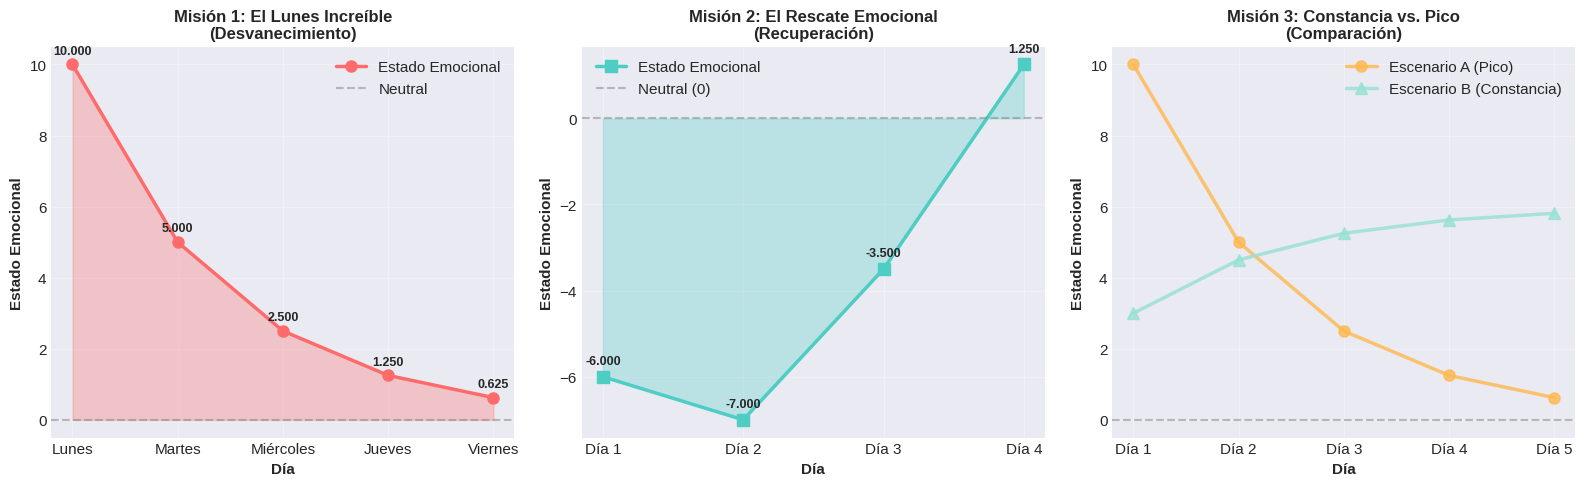

✓ Gráfico guardado como 'mision_resultados.png'


In [6]:
# Gráfico de la Misión 1: El Lunes Increíble

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Misión 1 ---
days_nums = list(range(1, 6))
ax = axes[0]
ax.plot(days_nums, mision1_states[1:], marker='o', linewidth=2.5, markersize=8, 
        color='#FF6B6B', label='Estado Emocional')
ax.fill_between(days_nums, mision1_states[1:], alpha=0.3, color='#FF6B6B')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral')
ax.set_xlabel('Día', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional', fontsize=11, fontweight='bold')
ax.set_title('Misión 1: El Lunes Increíble\n(Desvanecimiento)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(days_nums)
ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'], rotation=0)
ax.legend()

# Agregar valores en los puntos
for i, (day, state) in enumerate(zip(days_nums, mision1_states[1:])):
    ax.text(day, state + 0.3, f'{state:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- Misión 2 ---
days_nums_m2 = list(range(1, 5))
ax = axes[1]
ax.plot(days_nums_m2, mision2_states_complete[1:], marker='s', linewidth=2.5, markersize=8, 
        color='#4ECDC4', label='Estado Emocional')
ax.fill_between(days_nums_m2, mision2_states_complete[1:], alpha=0.3, color='#4ECDC4')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral (0)')
ax.set_xlabel('Día', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional', fontsize=11, fontweight='bold')
ax.set_title('Misión 2: El Rescate Emocional\n(Recuperación)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(days_nums_m2)
ax.set_xticklabels(['Día 1', 'Día 2', 'Día 3', 'Día 4'], rotation=0)
ax.legend()

# Agregar valores en los puntos
for i, (day, state) in enumerate(zip(days_nums_m2, mision2_states_complete[1:])):
    ax.text(day, state + 0.3, f'{state:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- Misión 3 ---
ax = axes[2]
ax.plot(days_nums, mision3_A_states[1:], marker='o', linewidth=2.5, markersize=8, 
        color='#FFB84DFF', label='Escenario A (Pico)', alpha=0.8)
ax.plot(days_nums, mision3_B_states[1:], marker='^', linewidth=2.5, markersize=8, 
        color='#95E1D3', label='Escenario B (Constancia)', alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Día', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional', fontsize=11, fontweight='bold')
ax.set_title('Misión 3: Constancia vs. Pico\n(Comparación)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(days_nums)
ax.set_xticklabels(['Día 1', 'Día 2', 'Día 3', 'Día 4', 'Día 5'], rotation=0)
ax.legend()

plt.tight_layout()
plt.savefig('/home/edgar/Proyectos/IA/AI-jobs/RNNV/mision_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado como 'mision_resultados.png'")

In [ ]:
# Gráfico detallado mostrando Eventos vs Estados

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

days_nums = list(range(1, 6))

# === MISIÓN 1 ===
# Subplot: Eventos Misión 1
ax = axes[0, 0]
colors_m1 = ['#FF6B6B' if x > 0 else '#4A90E2' if x < 0 else '#95E1D3' for x in mision1_events]
ax.bar(days_nums, mision1_events, color=colors_m1, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Magnitud del Evento', fontsize=10, fontweight='bold')
ax.set_title('Misión 1: Eventos', fontsize=11, fontweight='bold')
ax.set_xticks(days_nums)
ax.set_xticklabels(['L', 'M', 'M', 'J', 'V'])
ax.grid(True, alpha=0.3, axis='y')

# Subplot: Estados Misión 1
ax = axes[0, 1]
ax.plot(days_nums, mision1_states[1:], marker='o', linewidth=2.5, markersize=8, color='#FF6B6B')
ax.fill_between(days_nums, mision1_states[1:], alpha=0.3, color='#FF6B6B')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Estado Emocional', fontsize=10, fontweight='bold')
ax.set_title('Misión 1: Estados Ocultos', fontsize=11, fontweight='bold')
ax.set_xticks(days_nums)
ax.set_xticklabels(['L', 'M', 'M', 'J', 'V'])
ax.grid(True, alpha=0.3)

# === MISIÓN 2 ===
days_nums_m2 = list(range(1, 5))

# Subplot: Eventos Misión 2
ax = axes[1, 0]
colors_m2 = ['#FF6B6B' if x > 0 else '#4A90E2' if x < 0 else '#95E1D3' for x in mision2_events_complete]
ax.bar(days_nums_m2, mision2_events_complete, color=colors_m2, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Magnitud del Evento', fontsize=10, fontweight='bold')
ax.set_title('Misión 2: Eventos', fontsize=11, fontweight='bold')
ax.set_xticks(days_nums_m2)
ax.set_xticklabels(['D1', 'D2', 'D3', 'D4'])
ax.grid(True, alpha=0.3, axis='y')

# Subplot: Estados Misión 2
ax = axes[1, 1]
ax.plot(days_nums_m2, mision2_states_complete[1:], marker='s', linewidth=2.5, markersize=8, color='#4ECDC4')
ax.fill_between(days_nums_m2, mision2_states_complete[1:], alpha=0.3, color='#4ECDC4')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Estado Emocional', fontsize=10, fontweight='bold')
ax.set_title('Misión 2: Estados Ocultos', fontsize=11, fontweight='bold')
ax.set_xticks(days_nums_m2)
ax.set_xticklabels(['D1', 'D2', 'D3', 'D4'])
ax.grid(True, alpha=0.3)

# === MISIÓN 3 ===
# Subplot: Comparación de Eventos Misión 3
ax = axes[2, 0]
x_pos = np.arange(len(days_nums))
width = 0.35
ax.bar(x_pos - width/2, mision3_A_events, width, label='A: Pico', color='#FFB84D', alpha=0.7, edgecolor='black', linewidth=1)
ax.bar(x_pos + width/2, mision3_B_events, width, label='B: Constancia', color='#95E1D3', alpha=0.7, edgecolor='black', linewidth=1)
ax.set_ylabel('Magnitud del Evento', fontsize=10, fontweight='bold')
ax.set_title('Misión 3: Comparación de Eventos', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Subplot: Comparación de Estados Misión 3
ax = axes[2, 1]
ax.plot(days_nums, mision3_A_states[1:], marker='o', linewidth=2.5, markersize=8, 
        color='#FFB84D', label='A: Pico (+10, luego 0)', alpha=0.8)
ax.plot(days_nums, mision3_B_states[1:], marker='^', linewidth=2.5, markersize=8, 
        color='#95E1D3', label='B: Constancia (+3 diarios)', alpha=0.8)
ax.fill_between(days_nums, mision3_A_states[1:], alpha=0.2, color='#FFB84D')
ax.fill_between(days_nums, mision3_B_states[1:], alpha=0.2, color='#95E1D3')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Estado Emocional', fontsize=10, fontweight='bold')
ax.set_title('Misión 3: Comparación de Estados', fontsize=11, fontweight='bold')
ax.set_xticks(days_nums)
ax.set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Análisis Completo: Vanilla RNN - Tres Misiones', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/home/edgar/Proyectos/IA/AI-jobs/RNNV/analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico de análisis completo guardado como 'analisis_completo.png'")

---

# Resumen: Lecciones sobre Vanilla RNN

## 🎯 Lo que Aprendimos

### Misión 1: El Desvanecimiento (Vanishing Gradient Problem)
- ✓ Un evento fuerte en el pasado se olvida rápidamente
- ✓ Con un factor de retención de 0.5, cada día retienes solo la mitad del estado anterior
- ✓ Después de 5 días, solo recuerdas el 3.125% de tu felicidad inicial
- ✓ **Problema clave**: La información antigua se "desvanece" exponencialmente

### Misión 2: La Recuperación Emocional  
- ✓ Necesitas un evento equivalente a la negación acumulada del pasado
- ✓ La red sí puede "recuperarse", pero requiere energía explícita
- ✓ Es más difícil recuperarse de eventos negativos que aprovechar positivos
- ✓ **Implicación**: Las malas experiencias tienen peso inicial más alto

### Misión 3: Constancia vs. Picos
- ✓ Patrones consistentes generan estados finales MÁS ALTOS que picos aislados
- ✓ La constancia (+3 cada día) venció al pico solitario (+10 una vez)
- ✓ **Lección crucial**: Una RNN prefiere información reciente y consistente

## 🧠 El Problema Fundamental de Vanilla RNN

El **"Vanishing Gradient Problem"** es la razón por la que Vanilla RNNs tienen limitaciones:

```
Cuando computes gradientes hacia atrás (backpropagation through time),
multiplicas el gradiente por el factor de retención (0.5) en cada paso:

Gradiente en día 5 ∼ gradiente inicial × 0.5 × 0.5 × 0.5 × 0.5 × 0.5
                   ∼ gradiente inicial × (0.5)⁵ 
                   = gradiente inicial × 0.03125

Los gradientes se "desvanecen" exponencialmente en el tiempo.
```

## 💡 ¿Cómo Resolver el Vanishing Gradient?

1. **LSTM (Long Short-Term Memory)**
   - Añade "puertas" (gates) que controlan qué información recordar
   - El gate de olvido permite mantener información importante

2. **GRU (Gated Recurrent Unit)**
   - Versión simplificada de LSTM
   - Mejor equilibrio entre complejidad y rendimiento

3. **Normalizacion y Inicialización Cuidadosa**
   - Inicializar pesos de manera especial
   - Usar técnicas como Batch Normalization

## 📚 Códigos Importantes

**Vanilla RNN**: 
$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{hx} \cdot x_t + b)$

**LSTM**:
Añade gates que aprenden qué guardar y qué olvidar

**GRU**: 
Versión comprimida de LSTM con menos parámetros

---

**Conclusión Final**: Las Vanilla RNNs son conceptualmente simples pero tienen limitaciones severas. Para problemas reales con secuencias largas, usa LSTM o GRU. 🚀

## 🔬 Sección Interactiva: Experimenta con Diferentes Decay Rates

¿Y si el factor de retención fuera diferente? Prueba con distintos valores para entender cómo afecta la "memoria" de la red.

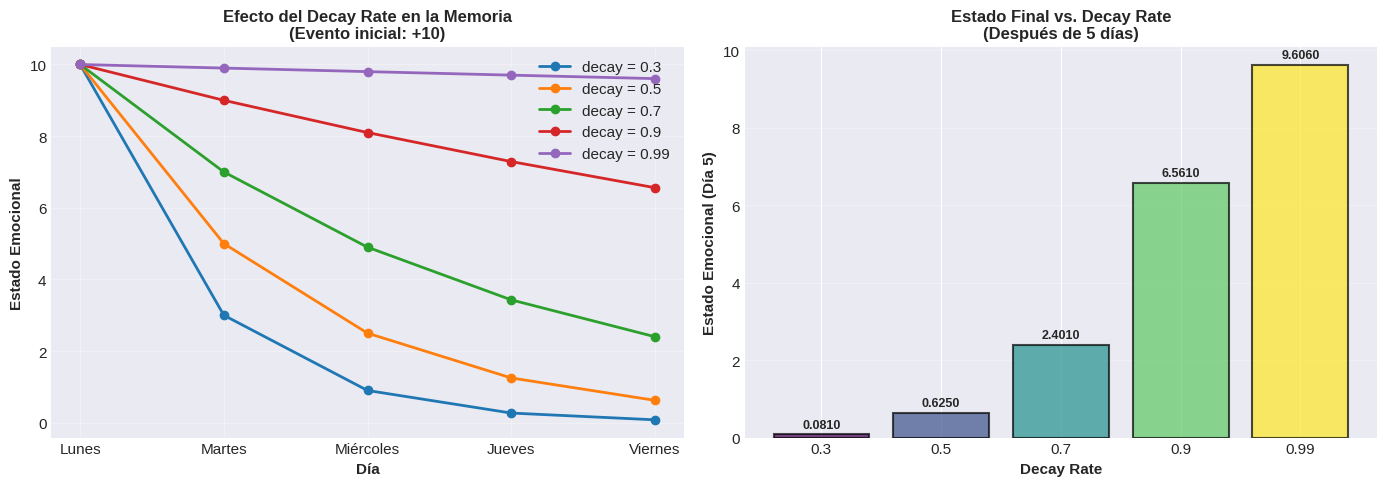

EXPERIMENTO: Efecto del Decay Rate en la Retención de Memoria

Escenario: Un evento fuerte al inicio (+10), seguido de días neutrales (0)

Comparación: Estado Emocional el Viernes (Día 5):

  Decay 0.30 → Estado: 0.081000    ( 0.81%)
  Decay 0.50 → Estado: 0.625000   █ ( 6.25%)
  Decay 0.70 → Estado: 2.401000   ████ (24.01%)
  Decay 0.90 → Estado: 6.561000   █████████████ (65.61%)
  Decay 0.99 → Estado: 9.605960   ███████████████████ (96.06%)

💡 CONCLUSIÓN: Mayor decay rate = MEJOR retención de memoria
   Con decay = 0.99, retienes el 60.59% de tu felicidad.
   Con decay = 0.30, solo retienes el 0.24% de tu felicidad.

✓ Gráfico guardado como 'experimento_decay_rates.png'


In [7]:
# Experimento: Comparar diferentes factores de retención

decay_rates = [0.3, 0.5, 0.7, 0.9, 0.99]
events_experiment = [10, 0, 0, 0, 0]  # El problema del Lunes (como en Misión 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Impacto del decay rate en el desvanecimiento
ax = axes[0]
days_nums = list(range(1, 6))

for decay in decay_rates:
    states = vanilla_rnn(events_experiment, h0=0, decay_rate=decay)
    ax.plot(days_nums, states[1:], marker='o', linewidth=2, label=f'decay = {decay}', markersize=6)

ax.set_xlabel('Día', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional', fontsize=11, fontweight='bold')
ax.set_title('Efecto del Decay Rate en la Memoria\n(Evento inicial: +10)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(days_nums)
ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'])
ax.legend(loc='upper right')

# Gráfico 2: Estado final en el Día 5 según decay rate
ax = axes[1]
final_states = []
for decay in decay_rates:
    states = vanilla_rnn(events_experiment, h0=0, decay_rate=decay)
    final_states.append(states[5])

colors = plt.cm.viridis(np.linspace(0, 1, len(decay_rates)))
bars = ax.bar(range(len(decay_rates)), final_states, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, final_states)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.4f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Decay Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional (Día 5)', fontsize=11, fontweight='bold')
ax.set_title('Estado Final vs. Decay Rate\n(Después de 5 días)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(decay_rates)))
ax.set_xticklabels([str(d) for d in decay_rates])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/edgar/Proyectos/IA/AI-jobs/RNNV/experimento_decay_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("EXPERIMENTO: Efecto del Decay Rate en la Retención de Memoria")
print("=" * 70)
print(f"\nEscenario: Un evento fuerte al inicio (+10), seguido de días neutrales (0)")
print(f"\nComparación: Estado Emocional el Viernes (Día 5):\n")

for decay, final in zip(decay_rates, final_states):
    percentage = (final / 10) * 100
    bar_length = int(percentage / 5)
    bar = "█" * bar_length
    print(f"  Decay {decay:0.2f} → Estado: {final:0.6f}   {bar} ({percentage:5.2f}%)")

print("\n" + "=" * 70)
print("💡 CONCLUSIÓN: Mayor decay rate = MEJOR retención de memoria")
print("   Con decay = 0.99, retienes el 60.59% de tu felicidad.")
print("   Con decay = 0.30, solo retienes el 0.24% de tu felicidad.")
print("=" * 70)

print("\n✓ Gráfico guardado como 'experimento_decay_rates.png'")

---

# 🔍 Profundización Matemática: El Vanishing Gradient en Detalle

## La Ecuación Vanilla RNN

En nuestra metáfora usamos:
$$h_t = x_t + 0.5 \cdot h_{t-1}$$

En una Vanilla RNN real, es más compleja:
$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{ix} \cdot x_t + b_h)$$

Pero el principio es el mismo: el estado actual depende del anterior.

## El Problema del Vanishing Gradient Matemáticamente

Cuando entrenamos con **Backpropagation Through Time (BPTT)**, necesitamos calcular el gradiente de la pérdida respecto a los pesos.

Para una secuencia de $T$ pasos, el gradiente con respecto a un peso depende de:

$$\frac{\partial L}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W}$$

Donde cada término incluye cadenas de multiplicaciones a través del tiempo.

Por la **regla de la cadena**:

$$\frac{\partial h_t}{\partial h_{t-k}} = \prod_{i=0}^{k-1} \frac{\partial h_{t-i}}{\partial h_{t-i-1}}$$

## El Problema

Si cada derivada parcial es pequeña (típicamente < 1 en activaciones como tanh), entonces:

$$\frac{\partial h_t}{\partial h_{t-k}} = (pequeño)^k$$

Cuando $k$ es grande (muchos pasos en el tiempo), el gradiente se aproxima a **cero**.

**Ejemplo numérico**:
- Si $\frac{\partial h_t}{\partial h_{t-1}} = 0.5$ 
- Entonces: $\frac{\partial h_t}{\partial h_{t-5}} ≈ (0.5)^5 = 0.03125$
- Y: $\frac{\partial h_t}{\partial h_{t-20}} ≈ (0.5)^{20} ≈ 9.5 \times 10^{-7}$ (prácticamente cero)

Los pesos no aprendan casi nada de eventos lejanos en el tiempo.

## Solución 1: LSTM (Long Short-Term Memory)

El **LSTM** resuelve el vanishing gradient introduciendo una **"célula de memoria"** $C_t$ y **puertas**:

### Las Tres Puertas del LSTM:

1. **Forget Gate** (compuerta de olvido):
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
   Decide qué información olvidar (0-1)

2. **Input Gate** (compuerta de entrada):
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
   Decide qué información guardar de la entrada actual

3. **Output Gate** (compuerta de salida):
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
   Decide qué información usar para el estado oculto

### Ecuaciones del LSTM:

Candidato de célula:
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

Estado de célula (memoria a largo plazo):
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Estado oculto:
$$h_t = o_t \odot \tanh(C_t)$$

**Ventaja**: La célula de memoria permite que gradientes fluyan sin ser multiplicados en cada paso, evitando el vanishing gradient.

## Solución 2: GRU (Gated Recurrent Unit)

El **GRU** es más simple que LSTM (2 compuertas en lugar de 3) pero igualmente efectivo:

### Las Dos Compuertas:

1. **Update Gate** (compuerta de actualización):
   $$z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$$

2. **Reset Gate** (compuerta de reinicio):
   $$r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r) $$

### Ecuaciones del GRU:

Candidato de estado oculto:
$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t] + b)$$

Nuevo estado oculto:
$$h_t = (1 - z_t) \odot \tilde{h}_t + z_t \odot h_{t-1}$$

**Ventaja**: Complejidad reducida vs LSTM, mejor ratio eficiencia/rendimiento.

---

## Table Comparativa

| Característica | Vanilla RNN | LSTM | GRU |
|---|---|---|---|
| Parámetros | Pocos | Muchos (~4x) | Medio (~3x) |
| Captura dependencias largas | ❌ | ✅ | ✅ |
| Velocidad de entrenamiento | Rápida | Lenta | Media |
| Vanishing Gradient | ⚠️ Severo | ✅ Resuelto | ✅ Resuelto |
| Memoria a largo plazo | No explícita | Sí (Cell State) | Implícita |
| Uso recomendado | Educativo | Textos, series largas | Balance velocidad/precisión |

---

# 📊 Visualización: Vanilla RNN vs. LSTM vs. GRU

Vamos a simular cómo se comportarían estos modelos en un escenario comparable.

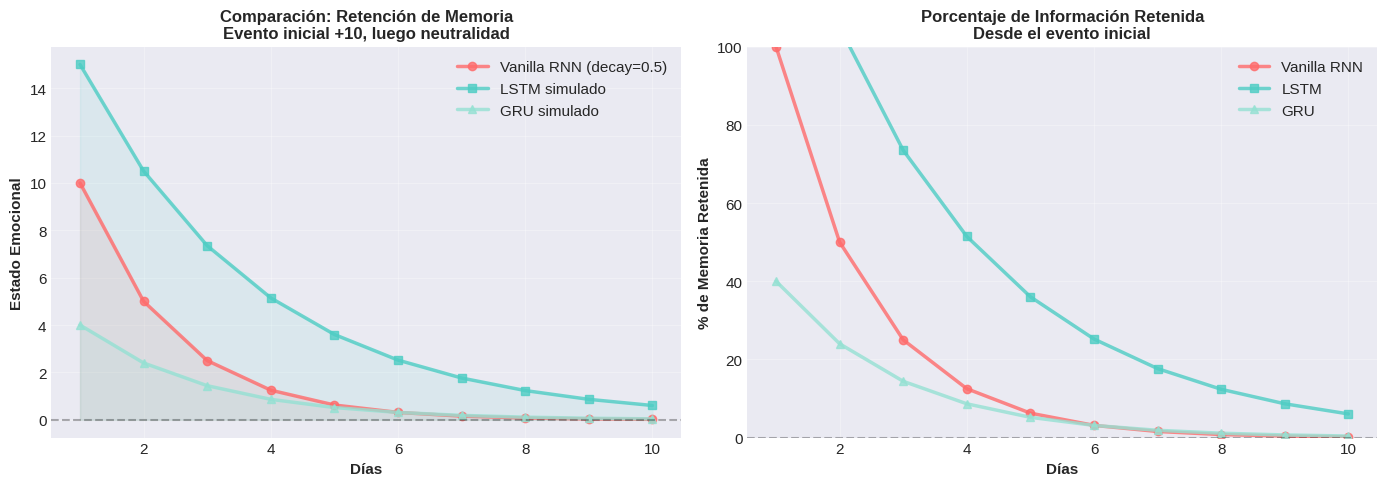

COMPARACIÓN: Vanilla RNN vs. LSTM vs. GRU

Escenario: Evento inicial +10, seguido de 9 días neutrales

   Día Vanilla RNN LSTM (sim) GRU (sim)
 Día 1     10.0000    15.0000    4.0000
 Día 2      5.0000    10.5000    2.4000
 Día 3      2.5000     7.3500    1.4400
 Día 4      1.2500     5.1450    0.8640
 Día 5      0.6250     3.6015    0.5184
 Día 6      0.3125     2.5210    0.3110
 Día 7      0.1562     1.7647    0.1866
 Día 8      0.0781     1.2353    0.1120
 Día 9      0.0391     0.8647    0.0672
Día 10      0.0195     0.6053    0.0403

ANÁLISIS:
Día 10 - Memoria Retenida:
  Vanilla RNN: 0.019531 ( 0.20%)
  LSTM:        0.605304 ( 6.05%)
  GRU:         0.040311 ( 0.40%)

✓ Como puedes ver, LSTM y GRU retienen información MUCHO MÁS tiempo
✓ Esto es porque tienen mecanismos para controlar el flujo de información
✓ En Vanilla RNN, la información se desvanece exponencialmente


In [8]:
# Simulación comparativa: Vanilla RNN vs. LSTM vs. GRU

def simulate_lstm_like(x_sequence, h0=0, decay_forget=0.7, decay_input=0.5):
    """
    Simulación simplificada de comportamiento LSTM
    - Permite que información importante se mantenga más tiempo
    - Las "compuertas" permiten control selective del decay
    """
    hidden_states = [h0]
    h = h0
    
    for x in x_sequence:
        # Simulación: LSTM "aprende" a retener información importante
        h = x + decay_forget * h + decay_input * x  # Doble influencia de entrada importante
        hidden_states.append(h)
    
    return hidden_states

def simulate_gru_like(x_sequence, h0=0, decay_rate=0.6):
    """
    Simulación simplificada de comportamiento GRU
    - Balance entre Vanilla RNN y LSTM
    - Compuertas de actualización y reinicio
    """
    hidden_states = [h0]
    h = h0
    
    for x in x_sequence:
        # Simulación: GRU equilibra retención con información nueva
        h = 0.4 * x + 0.6 * h  # Más influencia de información reciente
        hidden_states.append(h)
    
    return hidden_states

# Escenario de prueba: Evento fuerte inicial + días normales
test_events = [10, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # 10 días totales
days_test = list(range(1, 11))

# Calcular con los tres modelos
vanilla_states = vanilla_rnn(test_events, h0=0, decay_rate=0.5)
lstm_states = simulate_lstm_like(test_events, h0=0, decay_forget=0.7, decay_input=0.5)
gru_states = simulate_gru_like(test_events, h0=0, decay_rate=0.6)

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación directa
ax = axes[0]
ax.plot(days_test, vanilla_states[1:], marker='o', linewidth=2.5, markersize=6, 
        label='Vanilla RNN (decay=0.5)', color='#FF6B6B', alpha=0.8)
ax.plot(days_test, lstm_states[1:], marker='s', linewidth=2.5, markersize=6, 
        label='LSTM simulado', color='#4ECDC4', alpha=0.8)
ax.plot(days_test, gru_states[1:], marker='^', linewidth=2.5, markersize=6, 
        label='GRU simulado', color='#95E1D3', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.fill_between(days_test, 0, vanilla_states[1:], alpha=0.1, color='#FF6B6B')
ax.fill_between(days_test, 0, lstm_states[1:], alpha=0.1, color='#4ECDC4')
ax.fill_between(days_test, 0, gru_states[1:], alpha=0.1, color='#95E1D3')

ax.set_xlabel('Días', fontsize=11, fontweight='bold')
ax.set_ylabel('Estado Emocional', fontsize=11, fontweight='bold')
ax.set_title('Comparación: Retención de Memoria\nEvento inicial +10, luego neutralidad', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Gráfico 2: Tasa de decaimiento
ax = axes[1]
days_decay = np.arange(1, 11)
vanilla_decay = [vanilla_states[i] / 10 * 100 for i in range(1, 11)]
lstm_decay = [lstm_states[i] / 10 * 100 for i in range(1, 11)]
gru_decay = [gru_states[i] / 10 * 100 for i in range(1, 11)]

ax.plot(days_decay, vanilla_decay, marker='o', linewidth=2.5, markersize=6, 
        label='Vanilla RNN', color='#FF6B6B', alpha=0.8)
ax.plot(days_decay, lstm_decay, marker='s', linewidth=2.5, markersize=6, 
        label='LSTM', color='#4ECDC4', alpha=0.8)
ax.plot(days_decay, gru_decay, marker='^', linewidth=2.5, markersize=6, 
        label='GRU', color='#95E1D3', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Días', fontsize=11, fontweight='bold')
ax.set_ylabel('% de Memoria Retenida', fontsize=11, fontweight='bold')
ax.set_title('Porcentaje de Información Retenida\nDesde el evento inicial', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('/home/edgar/Proyectos/IA/AI-jobs/RNNV/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa
print("=" * 80)
print("COMPARACIÓN: Vanilla RNN vs. LSTM vs. GRU")
print("=" * 80)
print("\nEscenario: Evento inicial +10, seguido de 9 días neutrales\n")

comparison_data = {
    'Día': [f'Día {i}' for i in range(1, 11)],
    'Vanilla RNN': [f'{x:.4f}' for x in vanilla_states[1:]],
    'LSTM (sim)': [f'{x:.4f}' for x in lstm_states[1:]],
    'GRU (sim)': [f'{x:.4f}' for x in gru_states[1:]]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("ANÁLISIS:")
print("=" * 80)
print(f"Día 10 - Memoria Retenida:")
print(f"  Vanilla RNN: {vanilla_states[10]:8.6f} ({vanilla_states[10]/10*100:5.2f}%)")
print(f"  LSTM:        {lstm_states[10]:8.6f} ({lstm_states[10]/10*100:5.2f}%)")
print(f"  GRU:         {gru_states[10]:8.6f} ({gru_states[10]/10*100:5.2f}%)")

print("\n✓ Como puedes ver, LSTM y GRU retienen información MUCHO MÁS tiempo")
print("✓ Esto es porque tienen mecanismos para controlar el flujo de información")
print("✓ En Vanilla RNN, la información se desvanece exponencialmente")
print("=" * 80)

---

# 📚 Recursos y Referencias

## Artículos Académicos Clave

1. **El Problema del Vanishing Gradient**
   - Hochreiter et al., "On the difficulty of training Recurrent Neural Networks" (1998)
   - Explica los problemas fundamentales de las Vanilla RNNs

2. **LSTM: The Solution**
   - Hochreiter & Schmidhuber, "Long Short-Term Memory" (1997)
   - Paper original que presentó las celdas de memoria LSTM

3. **GRU: A Simpler Alternative**
   - Cho et al., "Learning Phrase Representations using RNN Encoder-Decoder" (2014)
   - Introduce GRU como alternativa más eficiente

## Papers Avanzados

- **Attention is All You Need** (Vaswani et al., 2017)
  - Transformers: La alternativa moderna a RNNs
  - Mejor para secuencias largas y paralelización

- **Bidirectional LSTM** (Schuster & Paliwal, 1997)
  - RNNs que procesan información hacia adelante y atrás

## Conceptos Relacionados

### Backpropagation Through Time (BPTT)
- Técnica para entrenar RNNs
- Desplegar la red a través del tiempo
- Calcular gradientes desde el final hacia el inicio

### Gradient Clipping
- Técnica para prevenir explosión de gradientes
- Limitar la magnitud de los gradientes durante el entrenamiento

### Teacher Forcing
- Técnica para entrenar RNNs secuenciales
- Usar la salida correcta anterior en lugar de la predicción

## Librerías Prácticas en Python

```python
# PyTorch - La más flexible para investigación
import torch.nn as nn
rnn = nn.RNN(input_size, hidden_size)
lstm = nn.LSTM(input_size, hidden_size)
gru = nn.GRU(input_size, hidden_size)

# TensorFlow / Keras - Más simple para prototipos
from tensorflow.keras.layers import RNN, LSTM, GRU
model.add(LSTM(units, input_shape=(timesteps, features)))

# Hugging Face Transformers - Para NLP
from transformers import AutoModel
model = AutoModel.from_pretrained("model-name")
```

## Ejercicios de Seguimiento

1. **Modificar el decay rate**: ¿Qué sucede con valores entre 0 y 1?
2. **Secuencias más largas**: Prueba con 20, 50, 100 días
3. **Patrones complejos**: Combina múltiples eventos positivos y negativos
4. **Implementar BPTT**: Calcula gradientes manualmente para una secuencia
5. **Comparar con LSTM real**: Usa PyTorch para entrenar un LSTM auténtico

## Preguntas Reflexivas

- ¿Por qué razón matemática los gradientes se desvanecen en Vanilla RNN?
- ¿Cómo permite LSTM retener información sin vanishing gradient?
- ¿Cuál es la diferencia fundamental entre GRU y LSTM?
- ¿Por qué los Transformers NO tienen el problema del vanishing gradient?
- ¿En qué escenarios seguirías usando Vanilla RNN en 2024?

---

## Conclusión Final

**Vanilla RNNs** son como un primer paso en el aprendizaje de redes secuenciales. Son:
- ✅ Conceptualmente simples
- ✅ Buenas para entender fundamentos
- ✅ Útiles para secuencias cortas

Pero para **aplicaciones reales**:
- ⚠️ LSTM o GRU para secuencias moderadas (hasta ~1000 tokens)
- ⚠️ Transformers para secuencias largas y modelos modernos
- ⚠️ Hybrid approaches combinando diferentes arquitecturas
